# 병렬 체인 (Parallel Chains)
- 여러 체인을 동시에 실행하여 다양한 관점의 답변을 얻을 수 있습니다.

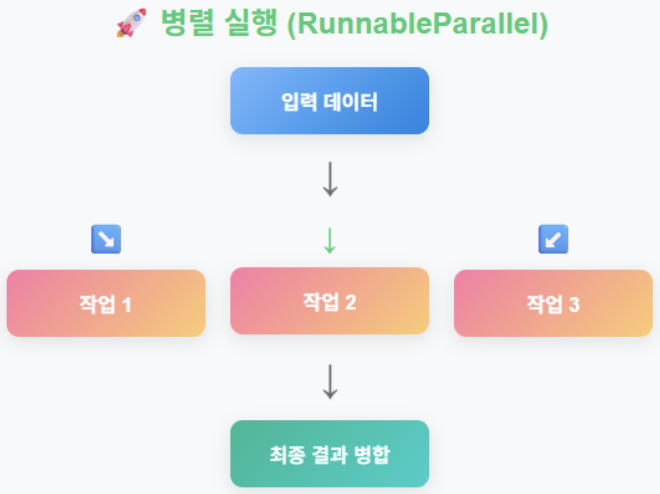

# Model

## [Groq API Key](https://console.groq.com/keys)

In [1]:
from dotenv import load_dotenv

# 환경변수 로드
load_dotenv()

True

## LLM

In [2]:
from langchain_groq import ChatGroq

# 정확한 모델 (Precise Model)
# - temperature 낮음 (0.1): 일관되고 정확한 답변
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1,
    model_kwargs={
        "top_p":1.0,                     # nucleus sampling (0.8~0.95 권장)
        "frequency_penalty":0.0,         # 반복 억제
        "presence_penalty":0.0,          # 새로운 아이디어 유도
    },
    max_tokens=2000
)

# Parser

In [3]:
from langchain_core.output_parsers import StrOutputParser

# OutputParser 설정
output_parser = StrOutputParser()

# 장점을 답변하는 체인 생성하기

In [4]:
from langchain_core.prompts import PromptTemplate

pros_prompt = PromptTemplate.from_template(
    template="""
        {topic}의 장점들을 나열해주세요.
    """
)

In [5]:
pros_chain = pros_prompt | model | output_parser

In [6]:
pros_chain

PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='\n        {topic}의 장점들을 나열해주세요.\n    ')
| ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000002786FCE8050>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002786FCE9010>, model_name='openai/gpt-oss-120b', temperature=0.1, model_kwargs={'top_p': 1.0, 'frequency_penalty': 0.0, 'presence_penalty': 0.0}, groq_api_key=SecretStr('**********'), max_tokens=2000)
| StrOutputParser()

# 단점을 답변하는 체인 생성하기

In [7]:
cons_prompt = PromptTemplate.from_template(
    template="""
        {topic}의 단점들을 나열해주세요.
    """
)

In [8]:
cons_chain = cons_prompt | model | output_parser

In [9]:
cons_chain

PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='\n        {topic}의 단점들을 나열해주세요.\n    ')
| ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000002786FCE8050>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002786FCE9010>, model_name='openai/gpt-oss-120b', temperature=0.1, model_kwargs={'top_p': 1.0, 'frequency_penalty': 0.0, 'presence_penalty': 0.0}, groq_api_key=SecretStr('**********'), max_tokens=2000)
| StrOutputParser()

# 전반적인 요약을 답변하는 체인 생성하기

In [10]:
summary_prompt = PromptTemplate.from_template(
    template="""
        {topic}의 대한 전반적인 요약을 해주세요.
    """
)

In [11]:
summary_chain = summary_prompt | model | output_parser

In [12]:
summary_chain

PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='\n        {topic}의 대한 전반적인 요약을 해주세요.\n    ')
| ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000002786FCE8050>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002786FCE9010>, model_name='openai/gpt-oss-120b', temperature=0.1, model_kwargs={'top_p': 1.0, 'frequency_penalty': 0.0, 'presence_penalty': 0.0}, groq_api_key=SecretStr('**********'), max_tokens=2000)
| StrOutputParser()

# RunnableParallel 체인 생성하기 

In [13]:
from langchain_core.runnables import RunnableParallel

# 각 체인들의 input_variables의 값이 똑같아야함!!!
parallel_chain = RunnableParallel({
    "pros": pros_chain,             # 긍정 
    "cons": cons_chain,             # 부정
    "summary": summary_chain        # 요약
})

In [14]:
# 병렬 실행
results = parallel_chain.invoke({"topic": "원격근무"})

In [15]:
results.keys()

dict_keys(['pros', 'cons', 'summary'])

In [16]:
print("=== 장점 ===")
print(results["pros"])

=== 장점 ===
원격근무(재택근무)의 주요 장점들을 정리하면 다음과 같습니다:

1. **시간·위치의 유연성**  
   - 출퇴근 시간 절감·교통 스트레스 감소  
   - 개인 일정(가족·학업·취미 등)과 업무를 보다 자유롭게 조율 가능  

2. **생산성 향상**  
   - 조용하고 집중하기 좋은 환경을 스스로 구성 가능  
   - 불필요한 회의·방해 요소를 최소화해 업무 효율 상승  

3. **비용 절감**  
   - 통근 교통비, 주차비, 식비 등 개인 비용 감소  
   - 기업 입장에서는 사무실 임대료·전기· 관리비 등 운영비 절감  

4. **인재 확보·다양성 확대**  
   - 지리적 제약 없이 전국·전 세계 인재를 채용 가능  
   - 다양한 배경·문화·연령대의 직원이 협업해 조직의 창의성·혁신성 강화  

5. **직장‑생활 균형(Work‑Life Balance) 개선**  
   - 가정·자녀·반려동물 돌봄 등 개인 생활과 업무를 동시에 관리하기 쉬움  
   - 스트레스 감소와 정신적·신체적 건강 증진에 기여  

6. **환경 친화적 효과**  
   - 통근 차량 감소로 탄소 배출량 및 교통 혼잡 완화  
   - 사무실 에너지 사용량 감소로 기업의 ESG(환경·사회·지배구조) 목표 달성에 도움  

7. **업무 연속성 및 재해 복구 능력 강화**  
   - 자연재해·전염병 등 비상 상황에서도 업무 지속 가능  
   - 클라우드·원격 협업 도구를 활용해 데이터와 업무 흐름을 안전하게 유지  

8. **직원 만족도·이직률 감소**  
   - 자율성과 신뢰를 기반으로 한 근무 환경이 직원 충성도와 만족도를 높임  
   - 이직·채용 비용 절감 효과가 기대됨  

9. **협업·커뮤니케이션 기술 활용 촉진**  
   - 화상 회의, 실시간 문서 공동 편집, 프로젝트 관리 툴 등 디지털 협업 도구 활용 능력 향상  
   - 업무 프로세스의 투명성과 추적 가능성이 높아짐  

10. **글로벌 협업 및 시차 활

In [17]:
print("\n=== 단점 ===")
print(results["cons"])


=== 단점 ===
**원격근무(재택근무)의 주요 단점**

| 구분 | 구체적인 단점 | 설명 |
|------|--------------|------|
| **소통·협업** | 실시간 대면 소통 부족 | 비언어적 신호(표정, 몸짓 등)를 놓치기 쉬워 오해가 발생할 수 있음 |
| | 회의·브레인스토밍 효율 저하 | 온라인 회의는 기술적 문제(네트워크 지연, 음질 저하)와 집중력 저하가 뒤따름 |
| | 정보 비대칭 | 팀 내에서 누가 어떤 일을 하고 있는지 파악하기 어려워 중복 작업이 늘어날 수 있음 |
| **업무·생산성** | 자기 관리 어려움 | 업무와 휴식 구분이 모호해 과도한 야근이나 반대로 업무 지연이 발생할 수 있음 |
| | 업무 흐름 파편화 | 여러 디지털 툴을 전환하면서 집중력이 분산되고 생산성이 떨어질 수 있음 |
| | 성과 측정 어려움 | 눈에 보이는 관리가 부족해 객관적인 성과 평가가 어려워 갈등이 생길 수 있음 |
| **조직 문화·동기부여** | 소속감·팀워크 약화 | 물리적 접촉이 적어 조직 문화 형성·유지에 어려움이 있음 |
| | 승진·평가 기회 불균형 | 관리자와 직접 마주하는 시간이 적어 눈에 띄는 기회가 줄어들 수 있음 |
| **심리·건강** | 고립감·외로움 | 동료와의 일상적인 대화가 사라져 사회적 고립감이 커질 수 있음 |
| | 스트레스·번아웃 | 업무와 생활 공간이 동일해 ‘일이 끝난다’는 느낌이 사라져 장시간 근무 위험이 증가 |
| | 신체적 불편 | 장시간 앉아 있는 자세, 적절하지 않은 가구·조명 등으로 근골격계 문제가 발생할 가능성 |
| **기술·보안** | 네트워크·장비 문제 | 인터넷 불안정, 하드웨어 고장 등으로 업무 차질이 발생할 수 있음 |
| | 데이터 보안 위험 | 개인 기기·네트워크 사용으로 기업 정보 유출 위험이 증가 |
| **법·제도** | 근로시간·수당 관리 어려움 | 근무시간 기록·초과수당 정산이 복잡해 법적 분쟁 가능성이 높아짐 |
| | 노동법 적용 한계 | 재택근무 

In [18]:
print("\n=== 요약 ===")
print(results["summary"])


=== 요약 ===
## 원격근무(리모트 워크) 개요

| 구분 | 내용 |
|------|------|
| **정의** | 사무실 등 고정된 근무 공간이 아닌, 집, 카페, 코워킹스페이스 등 **어디서든** 인터넷만 연결되면 업무를 수행할 수 있는 근무 형태 |
| **주요 형태** | 1. **전면 원격** – 전부 원격(재택·재택+코워킹) <br>2. **하이브리드** – 사무실 출근과 원격 근무를 주 1~3일 정도 번갈아 가는 형태 <br>3. **부분 원격** – 특정 업무(예: 개발, 디자인, 고객지원)만 원격 수행 |
| **역사·배경** | - 1990년대 인터넷·메일 보급 → 초기 원격 근무 시도 <br>- 2000~2010년 클라우드·협업 툴(구글 Docs, Dropbox) 등장 <br>- 2020년 COVID‑19 팬데믹으로 전 세계 기업·기관이 급격히 도입, “원격 근무 시대” 가속화 |
| **핵심 기술** | - **클라우드 스토리지** (Google Drive, OneDrive) <br>- **협업·커뮤니케이션 툴** (Slack, Teams, Zoom) <br>- **프로젝트 관리** (Asana, Trello, Jira) <br>- **보안·접속 관리** (VPN, Zero‑Trust, MFA) <br>- **디지털 워크플로우** (Zapier, Power Automate) |
| **주요 장점** | 1. **생산성 향상** – 통근 시간 절감, 집중 가능한 환경 선택 <br>2. **인재 확보 폭 확대** – 지리적 제약 없이 전 세계 인재 채용 가능 <br>3. **비용 절감** – 사무실 임대·전기·식대 등 운영비 감소 <br>4. **워라밸(Work‑Life Balance) 개선** – 유연한 근무시간·가족·취미와 병행 가능 |
| **주요 단점·리스크** | 1. **소통·협업 어려움** – 비대면으로 인한 오해·정보 누락 <br>2. **보안 위협** – 개인 기기·네트워크를 통한 데이터 유출 위험 <br>3. **